<h1 style = "color: #ce929d">Análisis de ventas y descuentos en minoristas </h1>
Laboratorio resuelto.

**Jane Andrey Méndez Blanco**


In [1]:
# Paso 1: Importar librerías necesarias
import pandas as pd  # Manejo de datos
import numpy as np   # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficos
import seaborn as sns  # Visualizaciones
from scipy.stats import zscore  # Cálculo de Z-Score

# Fijar semilla aleatoria para reproducibilidad
np.random.seed(42)

# Crear dataset base
data = {
    'ID_Venta': range(1, 201),
    'Sucursal': np.random.choice(['A','B','C','D','E'], 200),
    'Precio_Unitario': np.random.normal(15000, 3000, 200).round(2),
    'Cantidad': np.random.randint(1,10,200),
    'Descuento': np.random.normal(10,5,200).round(2)
}

df = pd.DataFrame(data)

# Calcular ingreso total
df['Ingreso_Total']=(df['Precio_Unitario']*df['Cantidad'])*(1-df['Descuento']/100)

# Agregar outliers intencionados
outliers=pd.DataFrame({
'ID_Venta':[201,202,203],
'Sucursal':['B','C','D'],
'Precio_Unitario':[80000,500,100000],
'Cantidad':[1,25,2],
'Descuento':[95,-10,120],
'Ingreso_Total':[10000,-2000,0]
})
df=pd.concat([df,outliers],ignore_index=True)
df.head()

,ID_Venta,Sucursal,Precio_Unitario,Cantidad,Descuento,Ingreso_Total
0,1,D,14863.79,5,6.24,69681.447520
1,2,E,15650.81,5,18.37,63878.781015
2,3,C,16537.27,3,10.22,44541.483018
3,4,E,16630.47,9,15.37,126669.300849
4,5,E,15084.30,4,10.38,54074.198640


<h4 style = "color: #ce929d"> Pregunta 1 </h4>

**Respuesta:** Crear un dataset con valores atípicos intencionales permite comprobar si los métodos de detección realmente funcionan y comparar los resultados obtenidos con distintas técnicas.

**Análisis del estudiante:** Es importante conocer el origen de los outliers porque algunos representan errores de captura y otros corresponden a situaciones reales del negocio.

In [2]:
# Exploración básica
df.info()
display(df.describe().round(2))

def missing_cols(df):
    total=0
    for col in df.columns:
        m=df[col].isnull().sum()
        total+=m
        if m!=0:
            print(col,m)
    if total==0:
        print("no missing values left")

missing_cols(df)

def perc_missing(df):
    for col in df.columns:
        pct=df[col].isna().mean()*100
        if pct!=0:
            print(col,round(pct,2))
perc_missing(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Venta         203 non-null    int64  
 1   Sucursal         203 non-null    object 
 2   Precio_Unitario  203 non-null    float64
 3   Cantidad         203 non-null    int64  
 4   Descuento        203 non-null    float64
 5   Ingreso_Total    203 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 9.6+ KB


,ID_Venta,Precio_Unitario,Cantidad,Descuento,Ingreso_Total
count,203.00,203.00,203.00,203.00,203.00
mean,102.00,15791.95,4.88,11.01,65125.23
std,58.75,8118.89,2.92,11.13,39455.33
min,1.00,500.00,1.00,-10.00,-2000.00
25%,51.50,13059.30,2.50,6.38,32298.23
50%,102.00,14965.25,5.00,10.28,62978.34
75%,152.50,16876.86,7.00,13.55,92729.58
max,203.00,100000.00,25.00,120.00,217620.49


no missing values left


<h4 style = "color: #ce929d"> Pregunta 2 </h4>

**Respuesta:** Valores máximos muy alejados del promedio, una desviación estándar elevada y una gran diferencia entre percentiles pueden indicar outliers.

**Análisis:** Precio_Unitario, Cantidad y Descuento presentan valores poco comunes que justifican una revisión.

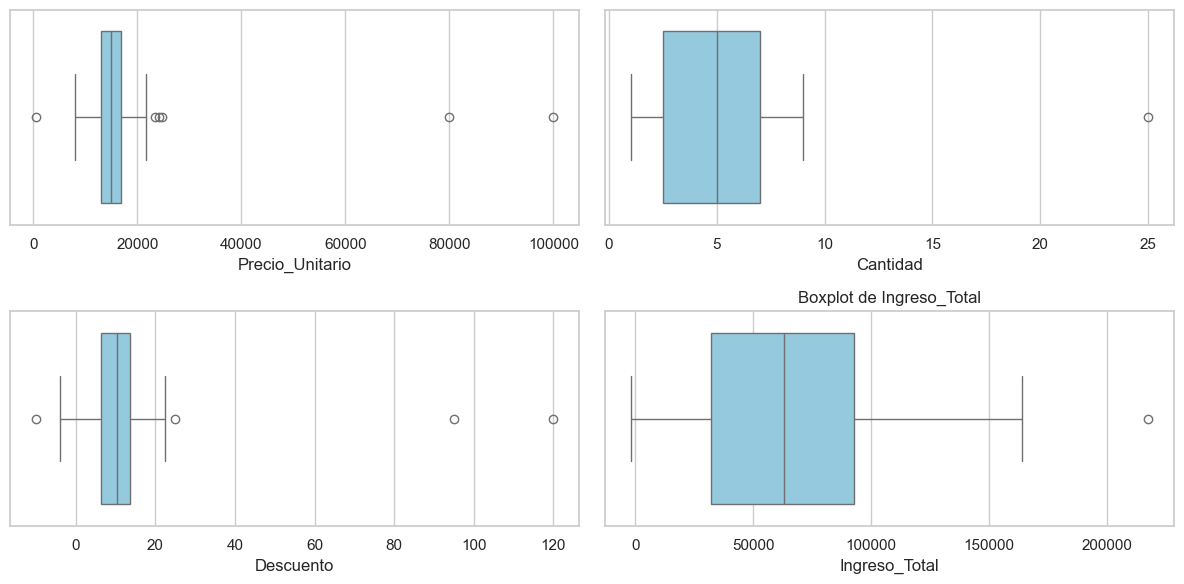

In [3]:
sns.set(style="whitegrid", palette="pastel")
variables = ['Precio_Unitario','Cantidad','Descuento','Ingreso_Total']
plt.figure(figsize=(12,6))
for i, var in enumerate(variables):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[var], color='skyblue')
plt.title(f'Boxplot de {var}')
plt.tight_layout()

<h4 style = "color: #ce929d"> Pregunta 3 </h4>

**Respuesta:** La variable **Precio_Unitario** presenta los valores más extremos.

**Análisis:** Puede tratarse de productos premium o de errores de digitación.


In [4]:
# Paso 4: Aplicar el método IQR en Precio_Unitario
Q1 = df['Precio_Unitario'].quantile(0.25)
Q3 = df['Precio_Unitario'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Precio_Unitario'] < lim_inf) | (df['Precio_Unitario'] > lim_sup)]
print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")
print(f"N° de outliers detectados por IQR: {outliers_iqr.shape[0]}")
outliers_iqr[['ID_Venta','Precio_Unitario','Sucursal']]

Límite inferior: 7332.95
Límite superior: 22603.21
N° de outliers detectados por IQR: 6


,ID_Venta,Precio_Unitario,Sucursal
49,50,24183.29,D
62,63,23351.81,E
193,194,24761.96,B
200,201,80000.00,B
201,202,500.00,C
202,203,100000.00,D


<h4 style = "color: #ce929d"> Pregunta 4 </h4>

**Respuesta:** El IQR es más robusto porque utiliza la mediana y los cuartiles, que son menos sensibles a valores extremos.

**Análisis:** Los percentiles mantienen la estabilidad del método aun cuando existen outliers.



In [5]:
# Ahora implementemos el modelo Z-score:

df['Z_Score'] = zscore(df['Descuento'])
umbral = 3
outliers_z = df[np.abs(df['Z_Score']) > umbral]
print(f"N° de outliers detectados por Z-Score: {outliers_z.shape[0]}")
outliers_z[['ID_Venta','Descuento','Z_Score']]

N° de outliers detectados por Z-Score: 2


,ID_Venta,Descuento,Z_Score
200,201,95.0,7.567194
202,203,120.0,9.819547


<h4 style = "color: #ce929d"> Pregunta 5 </h4>

**Respuesta:** El Z-Score supone una distribución aproximadamente normal.

**Análisis:** Si los datos están sesgados, puede clasificar incorrectamente algunos valores.



In [6]:
# Filtrar datasets sin outliers según cada método
df_iqr = df[(df['Precio_Unitario'] >= lim_inf) & (df['Precio_Unitario'] <= lim_sup)]
df_z = df[np.abs(df['Z_Score']) <= umbral]
print("Tamaño original:", df.shape)
print("Después de aplicar IQR:", df_iqr.shape)
print("Después de aplicar Z-Score:", df_z.shape)

Tamaño original: (203, 7)
Después de aplicar IQR: (197, 7)
Después de aplicar Z-Score: (201, 7)


<h4 style = "color: #ce929d"> Pregunta 6 </h4>

**Respuesta:** Normalmente el IQR elimina más registros cuando existen distribuciones sesgadas.

**Análisis:** Eliminar demasiados datos puede hacer perder información útil; eliminar pocos deja ruido.



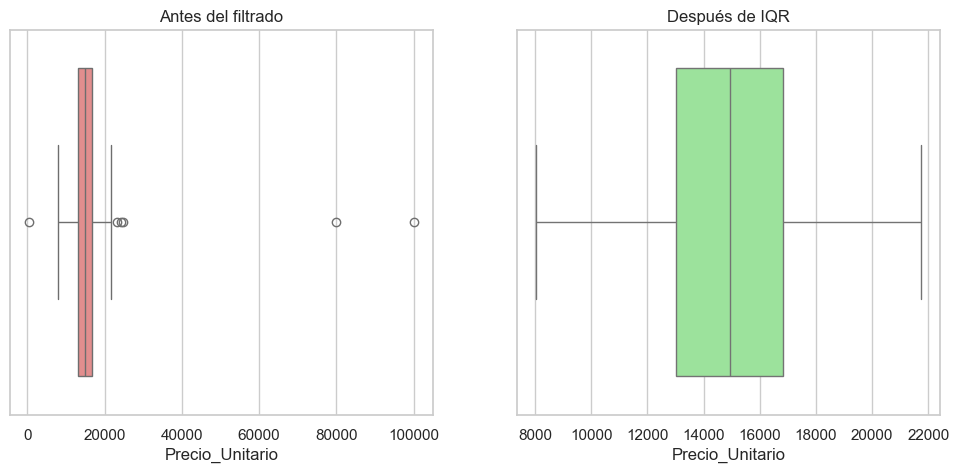

In [7]:
# Visualización comparativa después de limpieza
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(x=df['Precio_Unitario'], ax=axes[0], color='lightcoral')
sns.boxplot(x=df_iqr['Precio_Unitario'], ax=axes[1], color='lightgreen')
axes[0].set_title('Antes del filtrado')
axes[1].set_title('Después de IQR')
plt.show()

<h4 style = "color: #ce929d"> Pregunta 7 </h4>

**Respuesta:** El boxplot conserva la distribución principal y desaparecen los valores extremos.

**Análisis:** La dispersión disminuye sin alterar el comportamiento general de los datos.


<h4 style = "color: #ce929d">Reflexión Final </h4>

Al hacer este laboratorio, considero que el método **IQR** es el más adecuado para este conjunto de datos, ya que existen valores atípicos creados de forma intencional y algunas variables no presentan una distribución completamente normal. Al revisar la mediana y los cuartiles, el IQR logra identificar estos valores extremos sin verse tan afectado, lo que permite obtener un análisis más confiable.

Por otro lado, el **Z-Score** resulta útil cuando los datos siguen una distribución más o menos normal, ya que mide qué tan alejado se encuentra cada valor con respecto a la media. Sin embargo, cuando la información presenta sesgos o muchos valores extremos, puede verse afectado.

En un proyecto de **Machine Learning**, elegiría el método IQR para la limpieza de datos en áreas como ventas, finanzas o comercio, donde es común encontrar distribuciones no normales. En cambio, utilizaría el Z-Score para variables que mantienen un comportamiento más estable y cercano a una distribución normal.

Si el conjunto de datos fuera multimodal o incluyera variables no numéricas, consideraría otros métodos de detección de anomalías, como **Isolation Forest**, **DBSCAN** o **Local Outlier Factor (LOF)**, ya que estos permiten identificar observaciones atípicas incluso cuando los datos tienen estructuras más complejas.

En conclusión, este laboratorio me permitió comprobar que no existe un único método válido para todos los casos. La elección depende de las características del conjunto de datos y del objetivo del análisis, por lo que es importante comprender el contexto antes de decidir qué técnica utilizar.